# Import Necessary Packages

In [1]:
from pylab import *

# Custom Define Functions

In [2]:
def set_fig_properties(ax_list, panel_color_str='black', line_width=2):
    tl = 4
    tw = 2
    tlm = 2

    for ax in ax_list:
        ax.tick_params(which='major', length=tl, width=tw)
        ax.tick_params(which='minor', length=tlm, width=tw)
        ax.tick_params(which='both', axis='both', direction='in',
                       right=True, top=True)
        ax.spines['bottom'].set_color(panel_color_str)
        ax.spines['top'].set_color(panel_color_str)
        ax.spines['left'].set_color(panel_color_str)
        ax.spines['right'].set_color(panel_color_str)

        ax.spines['bottom'].set_linewidth(line_width)
        ax.spines['top'].set_linewidth(line_width)
        ax.spines['left'].set_linewidth(line_width)
        ax.spines['right'].set_linewidth(line_width)

        for t in ax.xaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.yaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.xaxis.get_ticklines(): t.set_linewidth(line_width)
        for t in ax.yaxis.get_ticklines(): t.set_linewidth(line_width)

# Denote Latex Font for Plots

In [3]:
# Denote plot default format
aw = 2
fs = 12
font = {'size': fs}
matplotlib.rc('font', **font)
matplotlib.rc('axes', linewidth=aw)

# Configure Matplotlib to use a LaTeX-like style without LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# Plot Phonon Spectra (Dispersion)

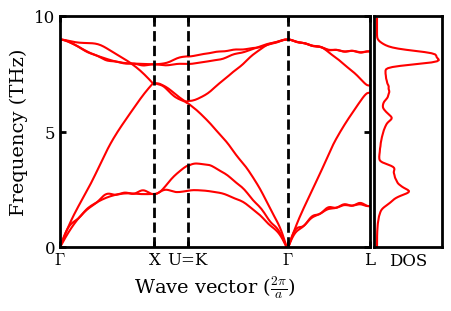

In [6]:
# Derive symbols for high symmetry directions in Brillouin zone
dispersion = np.loadtxt('plots/24_24_24/dispersion')
point_names = np.loadtxt('plots/24_24_24/point_names', dtype=str)

point_names_list = []
for point_name in point_names:
    if point_name == 'G':
        point_name = r'$\Gamma$'
    elif point_name == 'U':
        point_name = 'U=K'
    point_names_list.append(point_name)

# Load in the "tick-mark" values for these symbols
q = np.loadtxt('plots/24_24_24/q')
Q = np.loadtxt('plots/24_24_24/Q_val')
dos_Si = np.load('plots/24_24_24/dos.npy')

fig = figure(figsize=(4,3))
set_fig_properties([gca()])
plot(q[0], dispersion[0, 0], 'r-', ms=1)
plot(q, dispersion, 'r-', ms=1)
for i in range(1, 4):
    axvline(x=Q[i], ymin=0, ymax=2, ls='--',  lw=2, c="k")
ylabel('Frequency (THz)', fontsize=14)
xlabel(r'Wave vector ($\frac{2\pi}{a}$)', fontsize=14)
gca().set_yticks(np.arange(0, 30, 5))
xticks(Q, point_names_list)
ylim([0, 10])
xlim([Q[0], Q[4]])
dosax = fig.add_axes([0.91, .11, .17, .77])
set_fig_properties([gca()])
for d in np.expand_dims(dos_Si[1],0):
    dosax.plot(d, dos_Si[0],c='r')
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS")
ylim([0, 10])
show()